In [ ]:
import pandas as pd

df_global = pd.read_csv(filepath_or_buffer = './data/GLB.Ts+dSST.csv', sep = ',', header = 0, low_memory=False)
df_co2  = pd.read_csv(filepath_or_buffer = './data/owid-co2-data.csv', sep = ',', header = 0, low_memory=False)
df_zone  = pd.read_csv(filepath_or_buffer = './data/ZonAnn.Ts+dSST.csv', sep = ',', header = 0, low_memory=False)


In [6]:
df_co2.sort_values(by=['country'], ascending=False).head()

,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
50410,Zimbabwe,2024,ZWE,16634366.0,NaN,0.387493,0.023295,13.701154,0.257859,1.918125,...,NaN,0.102267,0.000542,0.000994,0.001716,0.00018,31.066437,20.773445,NaN,NaN
50228,Zimbabwe,1842,ZWE,758688.0,NaN,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50222,Zimbabwe,1836,ZWE,836674.0,NaN,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50223,Zimbabwe,1837,ZWE,823141.0,NaN,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50224,Zimbabwe,1838,ZWE,809827.0,NaN,0.000000,0.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_co2 = df_co2[
    (df_co2["country"] == "World") &
    (df_co2["year"] >= 1880)
][["year", "co2"]]

df_co2 = df_co2.dropna()

df_zone = df_zone.rename(columns={
    "Year": "year",
    "ZonAnn.Ts+dSST": "temperature"
})

df_zone = df_zone[df_zone["year"] >= 1880]
df_zone = df_zone.dropna()


In [4]:
df_plot.head()
df_plot.tail()


,year,Glob,NHem,SHem,24N-90N,24S-24N,90S-24S,64N-90N,44N-64N,24N-44N,EQU-24N,24S-EQU,44S-24S,64S-44S,90S-64S,co2
140,2020,1.00,1.34,0.67,1.66,0.84,0.57,2.86,1.81,1.18,0.87,0.81,0.59,0.39,0.84,35158.230469
141,2021,0.85,1.14,0.55,1.43,0.65,0.53,2.06,1.36,1.26,0.72,0.58,0.73,0.33,0.29,36866.863281
142,2022,0.89,1.16,0.62,1.52,0.56,0.71,2.35,1.50,1.27,0.62,0.49,0.79,0.40,1.07,37527.773438
143,2023,1.17,1.49,0.85,1.78,1.06,0.72,2.57,1.87,1.46,1.08,1.03,0.91,0.46,0.64,38094.039062
144,2024,1.28,1.65,0.91,1.95,1.18,0.74,2.90,1.95,1.65,1.21,1.15,0.88,0.54,0.67,38598.578125


KeyError: 'temperature'

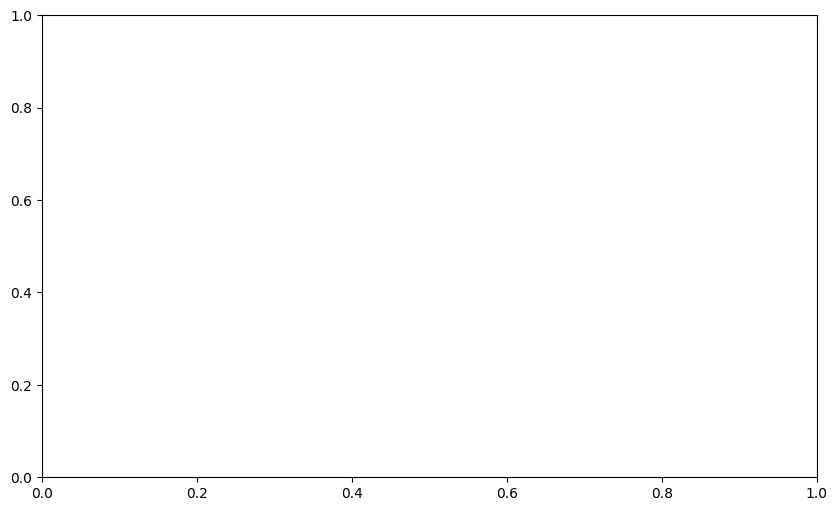

In [5]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 6))

# Trục trái: Temperature
ax1.plot(
    df_plot["year"],
    df_plot["temperature"],
    color="tab:blue",
    label="Temperature anomaly (°C)"
)
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature anomaly (°C)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# Trục phải: CO2
ax2 = ax1.twinx()
ax2.plot(
    df_plot["year"],
    df_plot["co2"],
    color="tab:red",
    label="CO₂ emissions (Gt)"
)
ax2.set_ylabel("CO₂ emissions (Gt)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Global temperature anomaly and CO₂ emissions since 1880")
fig.tight_layout()
plt.show()
